<a href="https://colab.research.google.com/github/FatherNurt/FUNt-Cosmologiical-Model-of-All-Things/blob/main/02_FUNt_Geometry_Engine_v1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FUNt Geometry Engine v1.0
## Subsolar, Dipole, GOES Local Time, and Geometry Ledger

Generated as part of the FUNt Transition Laboratory notebook suite.

## Purpose

Computes the geometry ledger independently from the transition engine.

This notebook should eventually hold precise subsolar point, dipole tilt, GSM/GSE transforms, GOES local time, and L1 lag geometry.

Current v1.0 uses transparent approximations suitable for audit and replacement.

In [1]:
import json
import math
import hashlib
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

UTC_NOW = datetime.now(timezone.utc)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

VERSION = "FUNt Geometry Engine v1.0"
CONFIG = {
    "version": VERSION,
    "geometry_floor": 0.40,
    "goes_longitude_deg": -75.2,
}
print(VERSION)


FUNt Geometry Engine v1.0


In [2]:
def solar_declination_deg(index):
    idx = pd.DatetimeIndex(index)
    idx = idx.tz_localize("UTC") if idx.tz is None else idx.tz_convert("UTC")
    doy = idx.dayofyear + (idx.hour + idx.minute/60 + idx.second/3600)/24.0
    return 23.44 * np.sin(2*np.pi*(doy - 81.0)/365.25)

def subsolar_longitude_deg(index):
    idx = pd.DatetimeIndex(index)
    idx = idx.tz_localize("UTC") if idx.tz is None else idx.tz_convert("UTC")
    hour = idx.hour + idx.minute/60 + idx.second/3600
    lon = 180.0 - 15.0 * hour
    return ((lon + 180) % 360) - 180

def approximate_dipole_tilt_deg(index):
    idx = pd.DatetimeIndex(index)
    idx = idx.tz_localize("UTC") if idx.tz is None else idx.tz_convert("UTC")
    hour = idx.hour + idx.minute/60 + idx.second/3600
    return solar_declination_deg(idx) + 6.5*np.cos(2*np.pi*(hour - 3.0)/24.0)

def goes_local_time_hours(index, goes_longitude_deg=-75.2):
    idx = pd.DatetimeIndex(index)
    idx = idx.tz_localize("UTC") if idx.tz is None else idx.tz_convert("UTC")
    hour = idx.hour + idx.minute/60 + idx.second/3600
    return (hour + goes_longitude_deg/15.0) % 24.0

def compute_geometry_ledger(index, cfg=CONFIG):
    sub_lat = solar_declination_deg(index)
    sub_lon = subsolar_longitude_deg(index)
    dipole = approximate_dipole_tilt_deg(index)
    goes_lt = goes_local_time_hours(index, cfg["goes_longitude_deg"])

    subsolar_factor = 1.0 - np.clip(np.abs(sub_lat)/23.44, 0, 1)*0.35
    tilt_factor = 0.5 + 0.5*np.cos(np.deg2rad(dipole - 10.0))
    lt_factor = 0.5 + 0.5*np.cos(2*np.pi*(goes_lt - 12.0)/24.0)
    rotation_factor = 0.5 + 0.5*np.cos(np.deg2rad(sub_lon))

    G_raw = 0.30*subsolar_factor + 0.30*tilt_factor + 0.25*lt_factor + 0.15*rotation_factor
    G = cfg["geometry_floor"] + (1 - cfg["geometry_floor"])*np.clip(G_raw, 0, 1)

    return pd.DataFrame({
        "subsolar_lat_deg": sub_lat,
        "subsolar_lon_deg": sub_lon,
        "dipole_tilt_deg_approx": dipole,
        "goes_local_time_hr": goes_lt,
        "geometry_subsolar_factor": subsolar_factor,
        "geometry_dipole_tilt_factor": tilt_factor,
        "geometry_goes_local_time_factor": lt_factor,
        "geometry_rotation_factor": rotation_factor,
        "G_total": G,
        "geometry_confidence": "approximate_scaffold",
    }, index=index)


,subsolar_lat_deg,subsolar_lon_deg,dipole_tilt_deg_approx,goes_local_time_hr,geometry_subsolar_factor,geometry_dipole_tilt_factor,geometry_goes_local_time_factor,geometry_rotation_factor,G_total,geometry_confidence
2026-06-17 17:18:01.138282+00:00,23.395274,-79.504167,18.038722,12.286944,0.650668,0.995087,0.998590,0.591082,0.899222,approximate_scaffold
2026-06-17 17:23:01.138282+00:00,23.395361,-80.754167,18.120406,12.370278,0.650667,0.994987,0.997653,0.580335,0.898096,approximate_scaffold
2026-06-17 17:28:01.138282+00:00,23.395447,-82.004167,18.204601,12.453611,0.650665,0.994882,0.996478,0.569551,0.896930,approximate_scaffold
2026-06-17 17:33:01.138282+00:00,23.395533,-83.254167,18.291266,12.536944,0.650664,0.994774,0.995068,0.558733,0.895725,approximate_scaffold
2026-06-17 17:38:01.138282+00:00,23.395619,-84.504167,18.380360,12.620278,0.650663,0.994661,0.993422,0.547887,0.894481,approximate_scaffold


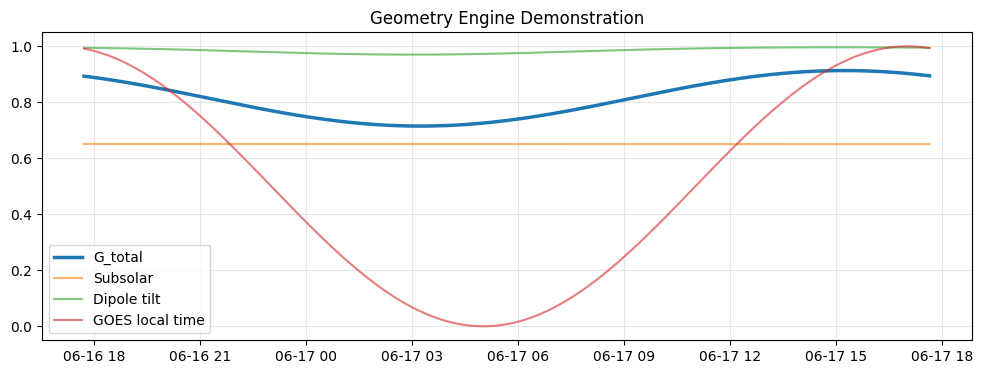

In [3]:
idx = pd.date_range(end=UTC_NOW, periods=288, freq="5min")
geom = compute_geometry_ledger(idx)
display(geom.tail())

plt.figure(figsize=(12,4))
plt.plot(geom.index, geom["G_total"], linewidth=2.5, label="G_total")
plt.plot(geom.index, geom["geometry_subsolar_factor"], alpha=0.6, label="Subsolar")
plt.plot(geom.index, geom["geometry_dipole_tilt_factor"], alpha=0.6, label="Dipole tilt")
plt.plot(geom.index, geom["geometry_goes_local_time_factor"], alpha=0.6, label="GOES local time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Geometry Engine Demonstration")
plt.show()
